In [1]:
%matplotlib widget

import os
import mne
import tqdm
import h5py
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from pyarrow.parquet import ParquetFile
from mne.io import concatenate_raws, read_raw_edf

from bscarlos.settings import OUTPUT_FOLDER
from bscarlos.settings import PROCESSED_KISPI_DATA_FOLDER
from bscarlos.detector_v3 import ClusteringDetector_v3
from bscarlos.data_processor_kispi import PatientDataProcessor

# KISPI (a1_6ch) Validation

This notebook runs the BSUPP algorithm on all KISPI patient data that was annotated and 'ground truth' labels by annotator1.

This assess how well the algorithm generalizes to new and 'unseen' KISPI pediatric EEG data.

Outputs in the form of metric scores (Sensitivity, Specificity, F1-scores, AUROC-scores/plots, NPV and MAE_bpm) from this notebook will be analyzed.

We will compare to USZ adult EEG data.

Additionally we will assess Cohen's Kappa to measure the interrater agreement three ways:
- annotator1 v. annotator2
- annotator1 v. BSUPP
- annotator2 v. BSUPP

In [2]:
data_files = sorted(list(PROCESSED_KISPI_DATA_FOLDER.glob('*a1_6ch_merged.parquet')))
data_attributes = pd.read_csv(PROCESSED_KISPI_DATA_FOLDER / 'data_attributes_kispi.csv').set_index("unique_patient_id")

In [3]:
data_files

[WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE008_a1_6ch_merged.parquet'),
 WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE021_a1_6ch_merged.parquet'),
 WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE026_a1_6ch_merged.parquet'),
 WindowsPath('C:/Users/c_arz/Documents/KISPI/Burst_Suppression_Project/Thesis/UnsuperDL-EEG-BSUPP/data/processed_kispi/SE038_a1_6ch_merged.parquet')]

In [4]:
data_attributes

,patient_id,start_datetime,end_sample,sample_rate
unique_patient_id,,,,
SE008_a1,P1,2012-04-17 17:02:08,2012-04-18 09:19:22.996093,256.0
SE021_a1,P2,2015-09-01 16:06:27,2015-09-01 16:30:26.996093,256.0
SE021_a2,P3,2015-09-01 16:06:27,2015-09-01 16:30:26.996093,256.0
SE026_a1,P4,2014-05-20 08:30:52,2014-05-20 09:40:12.996093,256.0
SE038_a1,P5,2018-05-23 11:05:57,2018-05-23 12:50:31.996093,256.0
SE038_a2,P6,2018-05-23 11:05:57,2018-05-23 12:50:31.996093,256.0


In [5]:
data_attributes.index

Index(['SE008_a1', 'SE021_a1', 'SE021_a2', 'SE026_a1', 'SE038_a1', 'SE038_a2'], dtype='object', name='unique_patient_id')

In [6]:
pfile = pq.read_table(data_files[0])
print("Column names: {}".format(pfile.column_names))
print("Schema: {}".format(pfile.schema))

Column names: ['Fp1-F7', 'F7-T3', 'T3-T5', 'Fp2-F8', 'F8-T4', 'T4-T6', 'ground_truth']
Schema: Fp1-F7: float
F7-T3: float
T3-T5: float
Fp2-F8: float
F8-T4: float
T4-T6: float
ground_truth: int64
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 1056


## 1. Preprocessing

### Create `patient_data` dictionary
store all relavant information for BSUPP Algorithm

In [7]:
dp = PatientDataProcessor()
patient_data =  dp.create_patient_data_dict(data_files, data_attributes)

100%|██████████| 4/4 [00:00<00:00, 24.04it/s]


In [8]:
for key in patient_data.keys():
    print(key)

SE008_a1
SE021_a1
SE026_a1
SE038_a1


Check sample rate frequency (`fs`) of all patients

In [9]:
for fs in patient_data:
    print(patient_data[fs]['fs'])

256.0
256.0
256.0
256.0


In [10]:
patient_data['SE021_a1']['data'].head(-1)

,Fp1-F7,F7-T3,T3-T5,Fp2-F8,F8-T4,T4-T6,ground_truth
0,34.186771,62.287937,-63.898834,90.389099,97.190659,143.369644,0
1,35.260700,60.856033,-67.836578,90.210129,95.579765,142.832687,0
2,34.902725,59.066147,-69.626465,89.494164,96.653694,142.295715,0
3,35.260704,56.918289,-68.731522,92.357986,97.369652,141.221786,0
4,36.155640,56.202335,-65.509727,95.758759,96.832687,142.295715,0
...,...,...,...,...,...,...,...
368634,64.077820,40.451363,-72.132294,93.431908,93.789886,154.108948,0
368635,63.361866,41.346306,-70.700394,92.894943,95.579773,151.245148,0
368636,61.750973,42.062252,-69.626457,94.505829,94.684830,150.171204,0
368637,60.319065,40.272377,-68.373543,94.147865,94.326843,148.023346,0


The data of each patient in this case SE021_a1 is in the form of a dataframe with 7 columns, the first 6 being the 6 derived montage bipolar channels with the seventh column being the labelled 'ground_truth' 0=no burst and 1=burst.

We now formed the 6 channel pairs with the following derivations:

 `bipolar_pairs = [`

      ('Fp1-F7': 'EEG Fp1', 'EEG F7'), 
      
      ('F7-T3': 'EEG F7', 'EEG T3'),

      ('T3-T5': 'EEG T3', 'EEG T5'),
      
     ('Fp2-F8': 'EEG Fp2', 'EEG F8'),

      ('F8-T4': 'EEG F8', 'EEG T4'), 
      
      ('T4-T6': 'EEG T4', 'EEG T6')]
  

In [17]:
def plot_eeg(df):
    """
    Plot all EEG channels in a single figure with scaling for specific channels.
    """
    t_s = df.index.total_seconds() if isinstance(df.index, pd.TimedeltaIndex) else df.index.astype('float') / 1e9

    plt.figure(figsize=(12, 8))

    for i, col in enumerate(df):
        scale = 1
        if str(col) not in {'Fp1-F7', 'F7-T3', 'T3-T5', 'Fp2-F8', 'F8-T4', 'T4-T6'}:
            scale = 50

        x = df[col].to_numpy()
        plt.plot(t_s, scale * x + 100 * i, label=col)

    plt.xlabel('Time [s]')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=4)
    plt.tight_layout()
    plt.show()

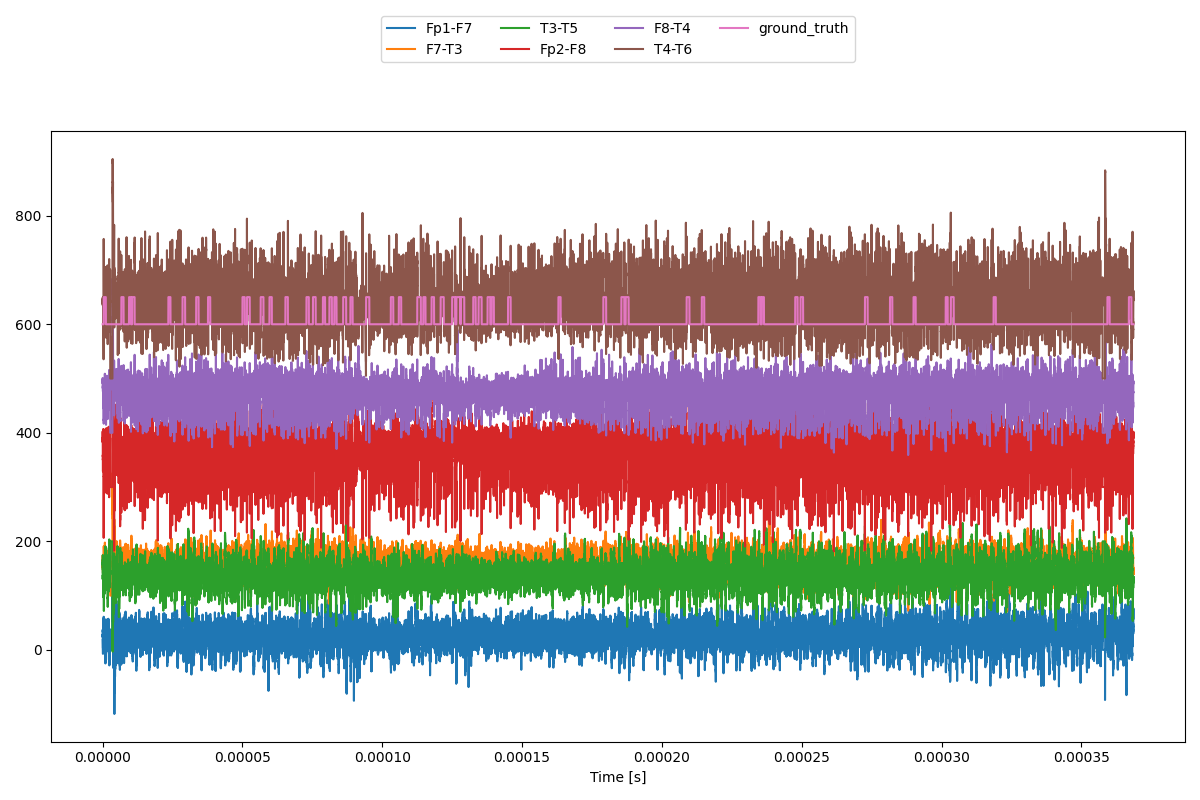

In [18]:
plot_eeg(patient_data['SE021_a1']['data'])

### Apply Bandpass Filter

In [19]:
dp.apply_bandpass_filter(patient_data)

100%|██████████| 4/4 [00:03<00:00,  1.02it/s]


{'SE008_a1': {'data':            Fp1-F7     F7-T3     T3-T5     Fp2-F8      F8-T4      T4-T6  \
  0       -0.531074 -2.525013 -4.015908  -2.326917  -2.799041   3.841022   
  1       -1.012581 -2.002285 -3.774007  -3.125789  -2.273698   3.617643   
  2       -1.477764 -1.487703 -3.548781  -3.879066  -1.779293   3.400406   
  3       -1.889377 -0.986272 -3.351429  -4.541964  -1.327108   3.205022   
  4       -2.216612 -0.502190 -3.189122  -5.082486  -0.923132   3.046445   
  ...           ...       ...       ...        ...        ...        ...   
  9511163  7.281094 -0.471812  7.848012  11.749183 -14.467382   7.196994   
  9511164  6.793112  0.150416  7.963563  10.437833 -11.883597   8.064836   
  9511165  6.201735  0.843714  7.941449   9.215543  -8.935477   9.181634   
  9511166  5.533332  1.587497  7.801830   8.036318  -5.810336  10.473768   
  9511167  4.819967  2.359029  7.578229   6.849496  -2.695150  11.848055   
  
           ground_truth  
  0                   0  
  1          

In [20]:
def plot_eeg_mne(eeg_data, sfreq, ch_names=None, ch_types=None, montage=None):
  if isinstance(eeg_data, pd.DataFrame):
    if ch_names is None:
      ch_names = eeg_data.columns.tolist()
    eeg_data = eeg_data.values.T  # Transpose for MNE format
  else:
    if ch_names is None:
      raise ValueError("ch_names must be provided if eeg_data is not a DataFrame")

  n_channels = eeg_data.shape[0]

  if ch_types is None:
    ch_types = ['eeg'] * n_channels

  info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

  raw = mne.io.RawArray(eeg_data, info)

  if montage is not None:
    raw.set_montage(montage)

  raw.plot(show_scrollbars=False, show_scalebars=True) 


Plot Filtered EEG Signals

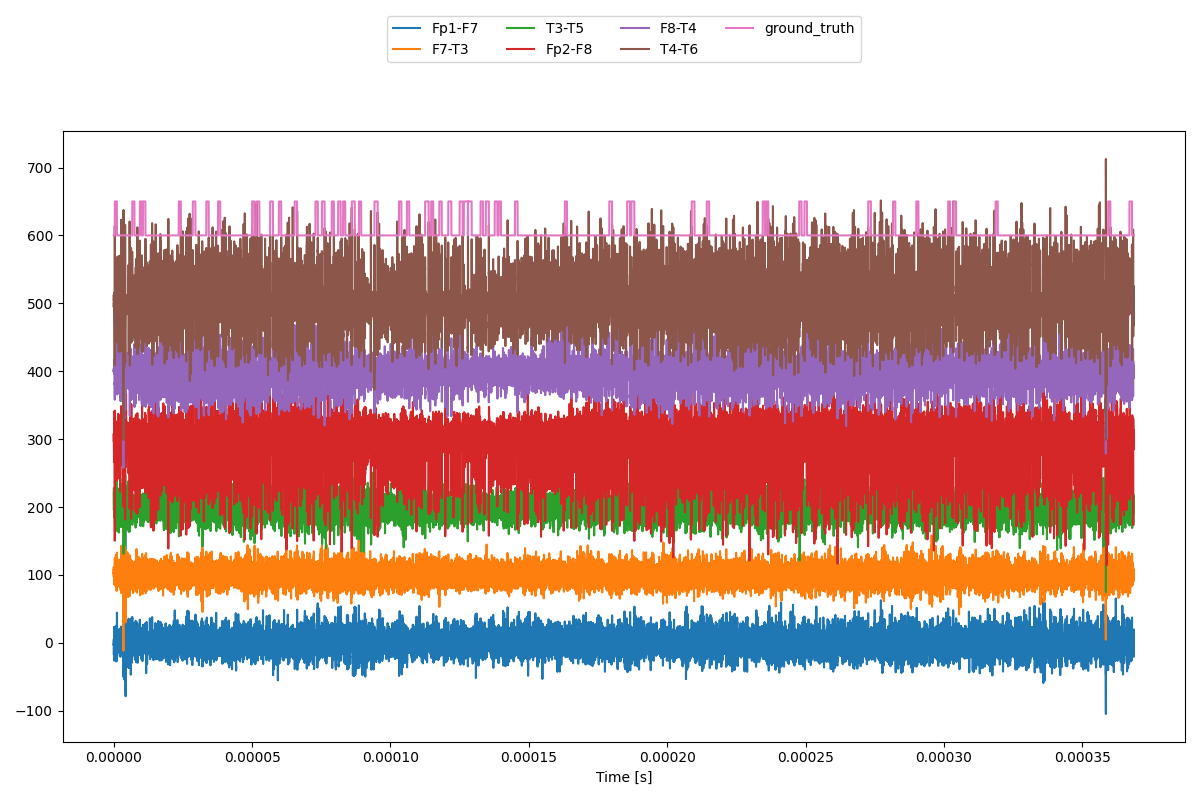

In [21]:
plot_eeg(patient_data['SE021_a1']['data'])

### Apply Timedelta Index

In [22]:
dp.apply_timedelta_index(patient_data)

100%|██████████| 4/4 [00:00<00:00, 93.97it/s]


{'SE008_a1': {'data':                              Fp1-F7     F7-T3     T3-T5     Fp2-F8      F8-T4  \
  0 days 00:00:00           -0.531074 -2.525013 -4.015908  -2.326917  -2.799041   
  0 days 00:00:00.003906250 -1.012581 -2.002285 -3.774007  -3.125789  -2.273698   
  0 days 00:00:00.007812500 -1.477764 -1.487703 -3.548781  -3.879066  -1.779293   
  0 days 00:00:00.011718750 -1.889377 -0.986272 -3.351429  -4.541964  -1.327108   
  0 days 00:00:00.015625    -2.216612 -0.502190 -3.189122  -5.082486  -0.923132   
  ...                             ...       ...       ...        ...        ...   
  0 days 10:19:12.980468750  7.281094 -0.471812  7.848012  11.749183 -14.467382   
  0 days 10:19:12.984375     6.793112  0.150416  7.963563  10.437833 -11.883597   
  0 days 10:19:12.988281250  6.201735  0.843714  7.941449   9.215543  -8.935477   
  0 days 10:19:12.992187500  5.533332  1.587497  7.801830   8.036318  -5.810336   
  0 days 10:19:12.996093750  4.819967  2.359029  7.578229   6.84949

### Create Learning and Testing Data
Seprating data based on:
- Learning period == first 15min of the data
- Testing period >= learning period of the data

This creates a variety in Train/Test split but follows the original papers data split instructions.

In [23]:
dp.split_data_with_15min_learning_period(patient_data)

100%|██████████| 4/4 [00:00<00:00, 13.12it/s]


{'SE008_a1': {'data':                              Fp1-F7     F7-T3     T3-T5     Fp2-F8      F8-T4  \
  0 days 00:00:00           -0.531074 -2.525013 -4.015908  -2.326917  -2.799041   
  0 days 00:00:00.003906250 -1.012581 -2.002285 -3.774007  -3.125789  -2.273698   
  0 days 00:00:00.007812500 -1.477764 -1.487703 -3.548781  -3.879066  -1.779293   
  0 days 00:00:00.011718750 -1.889377 -0.986272 -3.351429  -4.541964  -1.327108   
  0 days 00:00:00.015625    -2.216612 -0.502190 -3.189122  -5.082486  -0.923132   
  ...                             ...       ...       ...        ...        ...   
  0 days 10:19:12.980468750  7.281094 -0.471812  7.848012  11.749183 -14.467382   
  0 days 10:19:12.984375     6.793112  0.150416  7.963563  10.437833 -11.883597   
  0 days 10:19:12.988281250  6.201735  0.843714  7.941449   9.215543  -8.935477   
  0 days 10:19:12.992187500  5.533332  1.587497  7.801830   8.036318  -5.810336   
  0 days 10:19:12.996093750  4.819967  2.359029  7.578229   6.84949

In [24]:
def format_timedelta(td):
  """Formats a timedelta object into HH:MM:SS string."""
  total_seconds = int(td.total_seconds())
  hours, remainder = divmod(total_seconds, 3600)
  minutes, seconds = divmod(remainder, 60)
  return f"{hours:02d}:{minutes:02d}:{seconds:02d}"

for patient_id, patient_info in patient_data.items():
  train_duration = patient_data[patient_id]['training_data'].index[-1] - patient_data[patient_id]['training_data'].index[0]
  test_duration = patient_data[patient_id]['testing_data'].index[-1] - patient_data[patient_id]['testing_data'].index[0]

  print(f"Training Data {patient_id}: {format_timedelta(train_duration)}")
  print(f"Testing  Data {patient_id}: {format_timedelta(test_duration)}") 

Training Data SE008_a1: 00:14:59
Testing  Data SE008_a1: 10:04:12
Training Data SE021_a1: 00:14:59
Testing  Data SE021_a1: 00:08:59
Training Data SE026_a1: 00:14:59
Testing  Data SE026_a1: 00:14:59
Training Data SE038_a1: 00:14:59
Testing  Data SE038_a1: 00:15:29


### Create EEG-only Data 
Dropping 'ground_truth' column from learning and testing datasets


In [25]:
dp.remove_ground_truth_column(patient_data)

100%|██████████| 4/4 [00:00<00:00, 33.47it/s]


{'SE008_a1': {'data':                              Fp1-F7     F7-T3     T3-T5     Fp2-F8      F8-T4  \
  0 days 00:00:00           -0.531074 -2.525013 -4.015908  -2.326917  -2.799041   
  0 days 00:00:00.003906250 -1.012581 -2.002285 -3.774007  -3.125789  -2.273698   
  0 days 00:00:00.007812500 -1.477764 -1.487703 -3.548781  -3.879066  -1.779293   
  0 days 00:00:00.011718750 -1.889377 -0.986272 -3.351429  -4.541964  -1.327108   
  0 days 00:00:00.015625    -2.216612 -0.502190 -3.189122  -5.082486  -0.923132   
  ...                             ...       ...       ...        ...        ...   
  0 days 10:19:12.980468750  7.281094 -0.471812  7.848012  11.749183 -14.467382   
  0 days 10:19:12.984375     6.793112  0.150416  7.963563  10.437833 -11.883597   
  0 days 10:19:12.988281250  6.201735  0.843714  7.941449   9.215543  -8.935477   
  0 days 10:19:12.992187500  5.533332  1.587497  7.801830   8.036318  -5.810336   
  0 days 10:19:12.996093750  4.819967  2.359029  7.578229   6.84949

In [26]:
print(patient_data['SE021_a1']['training_data'])
print(patient_data['SE021_a1']['eeg_training'])

print(patient_data['SE021_a1']['training_data'].shape)
print(patient_data['SE021_a1']['eeg_training'].shape)

print(patient_data['SE021_a1']['testing_data'].shape)
print(patient_data['SE021_a1']['eeg_testing'].shape)

                              Fp1-F7      F7-T3      T3-T5    Fp2-F8  \
0 days 00:00:00            -0.940371   2.101030  -3.639396 -2.651758   
0 days 00:00:00.003906250  -0.814315   1.838683  -2.976470 -0.063030   
0 days 00:00:00.007812500  -0.737637   1.655301  -2.218802  2.367600   
0 days 00:00:00.011718750  -0.768597   1.622726  -1.307191  4.493682   
0 days 00:00:00.015625     -0.946155   1.797437  -0.205985  6.192478   
...                              ...        ...        ...       ...   
0 days 00:14:59.980468750   9.581660  20.561265  26.638320  9.663433   
0 days 00:14:59.984375     10.089511  20.950865  26.472224  9.195136   
0 days 00:14:59.988281250  10.687891  21.051518  26.197466  8.652058   
0 days 00:14:59.992187500  11.355785  20.932939  25.780475  8.076650   
0 days 00:14:59.996093750  12.054582  20.675058  25.201256  7.507897   

                              F8-T4     T4-T6  ground_truth  
0 days 00:00:00            0.426335 -0.212727             0  
0 days 00:0

In [27]:
patient_data['SE021_a1'].keys()

dict_keys(['data', 'fs', 'training_data', 'testing_data', 'eeg_training', 'eeg_testing'])

## 2. Train & Test

### Apply Clustering Detector on ALL (a1) patients

In [28]:
from joblib import Parallel, delayed
import pandas as pd

# Define the function to process each patient (this will be run in parallel)
def process_patient(patient_id, patient_info):
    eeg_training = patient_info['eeg_training']
    eeg_testing = patient_info['eeg_testing']
    
    # Initialize the detector and fit the model
    detector = ClusteringDetector_v3()
    detector.fit(eeg_training)  # X_train
    
    # Make predictions and get other required data
    predictions = detector.predict(eeg_testing)  # X_test
    labels = detector.labels_
    
    cov_matrices = detector.cov_matrices_
    metric_d = detector.metric_d_

    # Store results for this patient
    return patient_id, {
        'predictions': predictions,
        'labels': labels,
        'cov_matrices': cov_matrices,
        'metric_d': metric_d
    }

# Use Parallel and delayed to process all patients in parallel
results_for_analysis = {}

# Run the processing in parallel across all patients using 12 cores
results = Parallel(n_jobs=12)(  # Use all 12 cores
    delayed(process_patient)(patient_id, patient_info)
    for patient_id, patient_info in patient_data.items()
)

# Convert the results to a dictionary
for patient_id, result in results:
    results_for_analysis[patient_id] = result

# Convert results to a DataFrame
detector_results = pd.DataFrame(results_for_analysis).T

In [29]:
print(detector_results.keys())
print(detector_results.head(-1))

Index(['predictions', 'labels', 'cov_matrices', 'metric_d'], dtype='object')
                                                predictions  \
SE008_a1  [1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, ...   
SE021_a1  [1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, ...   
SE026_a1  [1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, ...   

                                                     labels  \
SE008_a1  [1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, ...   
SE021_a1  [0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, ...   
SE026_a1  [0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, ...   

                                               cov_matrices  \
SE008_a1  [[[23.909551782879888, 3.8603213245463768, 6.9...   
SE021_a1  [[[129.1521418973401, 12.554749509751, -32.724...   
SE026_a1  [[[1.1200658842232343, -0.43501252623619957, 0...   

                                                   metric_d  
SE008_a1  [[1.884110950420531e-15, 6.553309928838275, 7....  
SE021_a1  [[1.3322676295501877e-15, 7.03

In [30]:
patient_data['SE021_a1']['testing_data']['ground_truth'].shape

(138240,)

In [31]:
print(patient_data['SE021_a1']['testing_data']['ground_truth'])
ground_truth_labels = patient_data['SE021_a1']['testing_data']['ground_truth'].values
print(ground_truth_labels)


0 days 00:15:00              0
0 days 00:15:00.003906250    0
0 days 00:15:00.007812500    0
0 days 00:15:00.011718750    0
0 days 00:15:00.015625       0
                            ..
0 days 00:23:59.980468750    0
0 days 00:23:59.984375       0
0 days 00:23:59.988281250    0
0 days 00:23:59.992187500    0
0 days 00:23:59.996093750    0
Name: ground_truth, Length: 138240, dtype: int64
[0 0 0 ... 0 0 0]


In [32]:
patient_data['SE021_a1']['eeg_testing'].shape

(138240, 6)

In [33]:
results_for_analysis['SE021_a1']['labels'].shape

(450,)

In [34]:
results_for_analysis['SE021_a1']['predictions'].shape

(270,)

In [35]:
results_for_analysis.keys()

dict_keys(['SE008_a1', 'SE021_a1', 'SE026_a1', 'SE038_a1'])

In [36]:
def combine_windows_with_labels(windows, labels):
    label_datasets = []
    for label, window in zip(labels, windows):
        temp = pd.DataFrame(index=window.index, data={})
        temp['label'] = label
        label_datasets.append(temp)
    return pd.concat(label_datasets)

In [39]:
detector = ClusteringDetector_v3()

for patient_id, patient_info in patient_data.items():
    eeg_testing = patient_info['eeg_testing']

    labels_predicted = results_for_analysis[patient_id]['predictions']

    labels_frame_training = combine_windows_with_labels(detector.get_windows(eeg_testing), labels_predicted)
    
    data_testing_cropped_labeled = patient_info['testing_data'].copy()
    data_testing_cropped_labeled['label'] = labels_frame_training['label']

    # Append the new results to the existing dictionary
    results_for_analysis[patient_id].update({
        'data_testing_cropped_labeled': data_testing_cropped_labeled
    })

In [64]:
results_for_analysis["SE008_a1"]["data_testing_cropped_labeled"]

,Fp1-F7,F7-T3,T3-T5,Fp2-F8,F8-T4,T4-T6,ground_truth,label
0 days 00:15:00,5.253534,13.435057,29.020213,3.843753,23.462298,50.255653,0,1
0 days 00:15:00.003906250,5.844124,13.853212,30.130807,4.907265,24.666802,50.564087,0,1
0 days 00:15:00.007812500,6.331925,14.399598,30.935392,6.020603,25.601590,50.678853,0,1
0 days 00:15:00.011718750,6.691130,14.988333,31.326342,7.118521,26.263859,50.783899,0,1
0 days 00:15:00.015625,6.906170,15.527372,31.234738,8.117989,26.678713,51.057917,0,1
...,...,...,...,...,...,...,...,...
0 days 10:19:12.980468750,7.281094,-0.471812,7.848012,11.749183,-14.467382,7.196994,0,1
0 days 10:19:12.984375,6.793112,0.150416,7.963563,10.437833,-11.883597,8.064836,0,1
0 days 10:19:12.988281250,6.201735,0.843714,7.941449,9.215543,-8.935477,9.181634,0,1
0 days 10:19:12.992187500,5.533332,1.587497,7.801830,8.036318,-5.810336,10.473768,0,1


In [40]:
results_for_analysis["SE021_a1"]["data_testing_cropped_labeled"]

,Fp1-F7,F7-T3,T3-T5,Fp2-F8,F8-T4,T4-T6,ground_truth,label
0 days 00:15:00,12.731366,20.357078,24.455287,6.977775,6.393573,8.665011,0,1
0 days 00:15:00.003906250,13.324045,20.047735,23.553612,6.508770,6.732576,8.515186,0,1
0 days 00:15:00.007812500,13.767769,19.797982,22.521129,6.112617,6.942464,8.477268,0,1
0 days 00:15:00.011718750,14.001949,19.636972,21.393319,5.790280,7.036599,8.557729,0,1
0 days 00:15:00.015625,13.977106,19.571696,20.211808,5.533055,7.043443,8.742698,0,1
...,...,...,...,...,...,...,...,...
0 days 00:23:59.980468750,11.895308,-0.887747,-3.859510,-5.513503,2.624968,6.671063,0,0
0 days 00:23:59.984375,10.047062,-0.861268,-3.457632,-5.386922,1.839556,5.463674,0,0
0 days 00:23:59.988281250,8.104042,-0.797988,-3.072237,-5.104977,0.975378,4.203800,0,0
0 days 00:23:59.992187500,6.098183,-0.734972,-2.675128,-4.675719,0.073010,2.874485,0,0


In [63]:
results_for_analysis["SE026_a1"]["data_testing_cropped_labeled"]

,Fp1-F7,F7-T3,T3-T5,Fp2-F8,F8-T4,T4-T6,ground_truth,label
0 days 00:15:00,1.883155,-3.423907,2.740487,3.929741,-4.661361,-35.195621,0,1
0 days 00:15:00.003906250,2.217158,-3.041617,2.625934,3.842894,-4.992461,-31.180765,0,1
0 days 00:15:00.007812500,2.495708,-2.663957,2.450936,3.818644,-5.399008,-27.096394,0,1
0 days 00:15:00.011718750,2.716728,-2.288563,2.257910,3.857000,-5.858117,-23.001334,0,1
0 days 00:15:00.015625,2.884407,-1.909728,2.094435,3.952047,-6.340929,-18.947110,0,1
...,...,...,...,...,...,...,...,...
0 days 00:29:59.980468750,1.493921,11.495046,16.711513,5.022580,-3.744401,-11.484472,0,1
0 days 00:29:59.984375,0.831124,9.015627,15.836651,3.775609,-2.057129,-9.082085,0,1
0 days 00:29:59.988281250,0.181379,6.111930,14.743818,2.562595,-0.179529,-6.201029,0,1
0 days 00:29:59.992187500,-0.414305,2.980907,13.317241,1.385987,1.820405,-2.967531,0,1


In [65]:
results_for_analysis["SE038_a1"]["data_testing_cropped_labeled"]

,Fp1-F7,F7-T3,T3-T5,Fp2-F8,F8-T4,T4-T6,ground_truth,label
0 days 00:15:00,22.068922,1.327372,-10.209495,30.850319,17.006776,-13.624835,0,1
0 days 00:15:00.003906250,21.260433,0.953681,-11.354463,31.020914,17.742997,-13.983593,0,1
0 days 00:15:00.007812500,20.283427,0.470363,-12.342512,31.034250,18.440206,-13.986691,0,1
0 days 00:15:00.011718750,19.250858,-0.152666,-13.055973,30.910432,19.117331,-13.577275,0,1
0 days 00:15:00.015625,18.272891,-0.935763,-13.401024,30.675183,19.787908,-12.720367,0,1
...,...,...,...,...,...,...,...,...
0 days 00:30:29.980468750,-26.115814,14.041179,-2.395913,6.532815,-1.910232,-8.274418,0,1
0 days 00:30:29.984375,-21.110259,11.214699,-2.683240,5.231534,-1.297185,-7.664570,0,1
0 days 00:30:29.988281250,-15.192065,7.965714,-3.087433,3.641925,-0.493664,-7.029598,0,1
0 days 00:30:29.992187500,-8.613706,4.461004,-3.592157,1.852360,0.453855,-6.381863,0,1


In [79]:
results_for_analysis["SE021_a1"]

{'predictions': array([1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
        1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0,
        0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
        0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
        1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
        1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1,
        0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
        1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
        1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
        0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
        1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
        0, 1, 1, 1, 1, 0]),
 'labels': array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 

### Visualize EEG
Plot the EEG data for each patient, along with the predicted labels. To see how the detector is labeling different segments of the data.


In [41]:
def plot_eeg(df):
    t_s = (df.index/pd.Timedelta(1, 's')).to_numpy()

    plt.figure()

    for i, col in enumerate(df):

        scale = 1
        if str(col) not in {'Fp1-F7', 'F7-T3', 'T3-T5', 'Fp1-F3', 'F3-C3', 
                            'C3-P3', 'P3-O1', 'Fz-Cz', 'Cz-Pz', 'Fp2-F4', 
                            'F4-C4', 'C4-P4', 'P4-O2', 'Fp2-F8', 'F8-T4', 
                            'T4-T6', 'T6-O2'}:
            scale = 50

        x = df[col].to_numpy()
        plt.plot(t_s, scale*x+100*i, label=col)

    plt.xlabel('time [s]')

    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=4)
    plt.tight_layout()

In [44]:
def plot_eeg_multiple_new_new(df):
    """
    Plots EEG time series data with groundtruth labels highlighted, 
    each channel in a separate subplot with individual y-axis limits.
    """
    n_samples = len(df.index)
    data = df.to_numpy().T
    
    # extract the total seconds
    t_s = (df.index - df.index[0]).total_seconds()

    five_min = next((i for i, t in enumerate(t_s) if t > 300), n_samples)

    fig, axes = plt.subplots(len(df.columns[:-1]), 1, figsize=(12, 8), sharex=True)  # Create subplots

    for i, col in enumerate(df.columns[:-1]):
        x = data[i]
        ax = axes[i]  # Get the subplot for the current channel
        ax.plot(t_s[:five_min], x[:five_min], label=col)

        # Set y-axis limits for this channel (adjust as needed)
        y_min = np.min(x[:five_min]) - 10  # Example: min value - 10
        y_max = np.max(x[:five_min]) + 10  # Example: max value + 10
        ax.set_ylim(y_min, y_max)

        # Highlight groundtruth labels
        cmap = plt.cm.Reds
        groundtruth_labels = df['ground_truth'].values
        for j, label in enumerate(groundtruth_labels[:five_min]):
            if label == 1:
                ax.axvspan(t_s[j], t_s[j+1], alpha=0.5, color=cmap(0.7))

        # Highlight predicted labels
        cmap = plt.cm.Blues
        predicted_labels = df['label'].values
        for j, label in enumerate(predicted_labels[:five_min]):
            if label == 1:
                ax.axvspan(t_s[j], t_s[j+1], alpha=0.5, color=cmap(0.7))        

        ax.legend(loc='upper right')

    plt.xlabel('Time (s)')  # Set x-label for the bottom subplot
    plt.suptitle('EEG Data (First 5 minutes)')  # Set overall title
    plt.tight_layout()
    plt.show()

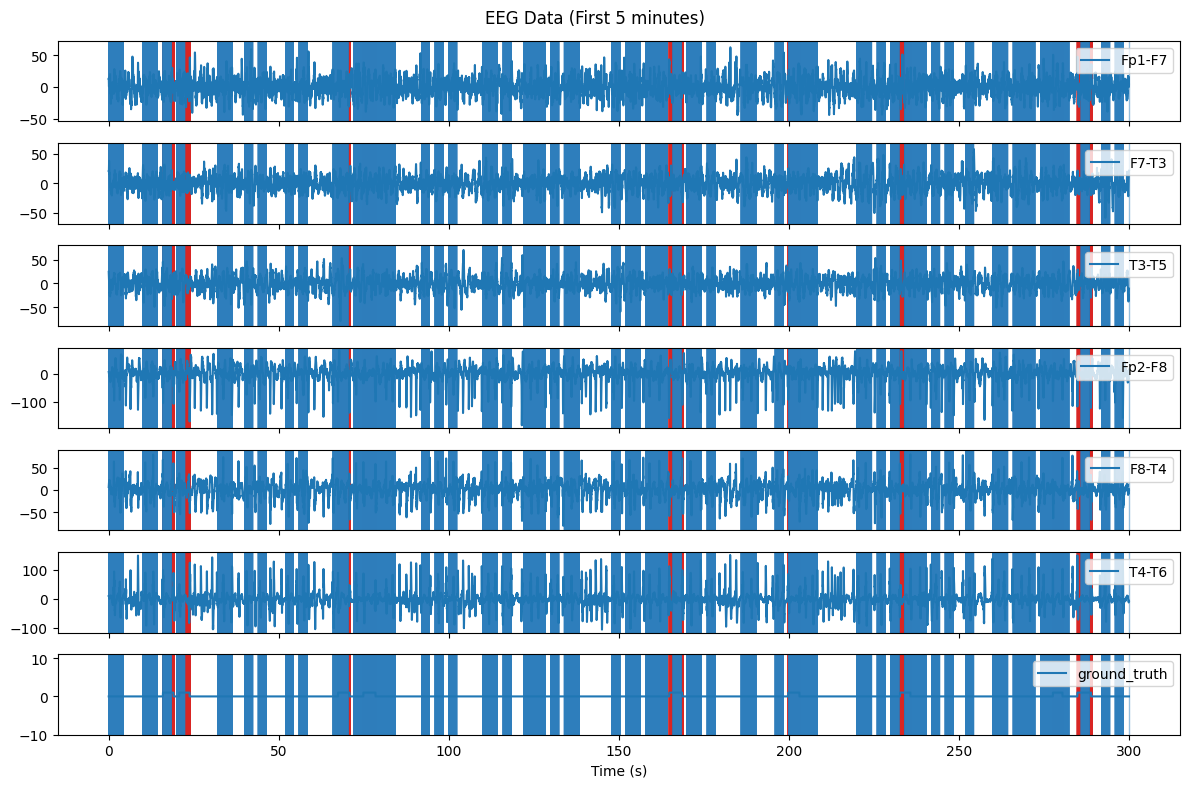

In [45]:
plot_eeg_multiple_new_new(results_for_analysis["SE021_a1"]["data_testing_cropped_labeled"])

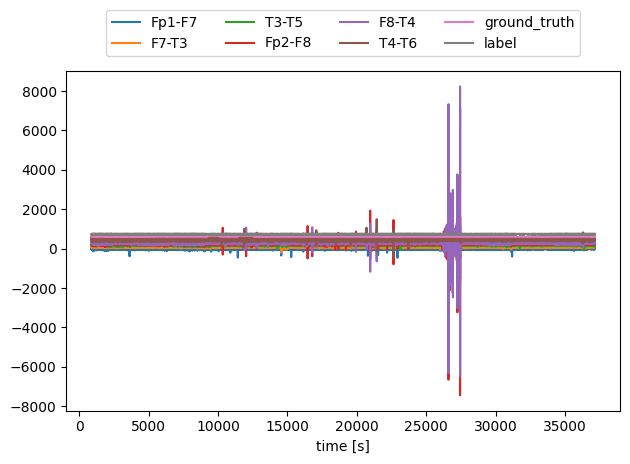

In [46]:
plot_eeg(results_for_analysis["SE008_a1"]["data_testing_cropped_labeled"])

In [48]:
detector_results

,predictions,labels,cov_matrices,metric_d
SE008_a1,"[1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, ...","[1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, ...","[[[23.909551782879888, 3.8603213245463768, 6.9...","[[1.884110950420531e-15, 6.553309928838275, 7...."
SE021_a1,"[1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, ...","[0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, ...","[[[129.1521418973401, 12.554749509751, -32.724...","[[1.3322676295501877e-15, 7.030832040284373, 8..."
SE026_a1,"[1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, ...","[0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, ...","[[[1.1200658842232343, -0.43501252623619957, 0...","[[1.1801832636420706e-15, 10.869030132629273, ..."
SE038_a1,"[1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, ...","[0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, ...","[[[0.931997246201145, 0.007485998913006375, 0....","[[5.0876810486276e-16, 11.88811310616606, 11.4..."


In [93]:
detector_results.iloc[0]

predictions     [1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, ...
labels          [1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, ...
cov_matrices    [[[23.909551782879888, 3.8603213245463768, 6.9...
metric_d        [[1.884110950420531e-15, 6.553309928838275, 7....
Name: SE008_a1, dtype: object

In [94]:
detector_results.iloc[1]

predictions     [1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, ...
labels          [0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, ...
cov_matrices    [[[129.1521418973401, 12.554749509751, -32.724...
metric_d        [[1.3322676295501877e-15, 7.030832040284373, 8...
Name: SE021_a1, dtype: object

In [95]:
detector_results.iloc[2]

predictions     [1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, ...
labels          [0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, ...
cov_matrices    [[[1.1200658842232343, -0.43501252623619957, 0...
metric_d        [[1.1801832636420706e-15, 10.869030132629273, ...
Name: SE026_a1, dtype: object

In [96]:
detector_results.iloc[3]

predictions     [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, ...
labels          [0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, ...
cov_matrices    [[[0.931997246201145, 0.007485998913006375, 0....
metric_d        [[5.0876810486276e-16, 11.88811310616606, 11.4...
Name: SE038_a1, dtype: object

##### Plot LEARNED labels SE008_a1

In [66]:
patient_data["SE008_a1"]["training_data"]

,Fp1-F7,F7-T3,T3-T5,Fp2-F8,F8-T4,T4-T6,ground_truth
0 days 00:00:00,-0.531074,-2.525013,-4.015908,-2.326917,-2.799041,3.841022,0
0 days 00:00:00.003906250,-1.012581,-2.002285,-3.774007,-3.125789,-2.273698,3.617643,0
0 days 00:00:00.007812500,-1.477764,-1.487703,-3.548781,-3.879066,-1.779293,3.400406,0
0 days 00:00:00.011718750,-1.889377,-0.986272,-3.351429,-4.541964,-1.327108,3.205022,0
0 days 00:00:00.015625,-2.216612,-0.502190,-3.189122,-5.082486,-0.923132,3.046445,0
...,...,...,...,...,...,...,...
0 days 00:14:59.980468750,1.979282,14.945089,23.800532,-0.231724,15.038292,42.031392,0
0 days 00:14:59.984375,2.560358,14.127452,24.351346,0.498578,16.817944,44.614217,0
0 days 00:14:59.988281250,3.210398,13.551837,25.264388,1.224461,18.624151,46.786167,0
0 days 00:14:59.992187500,3.899609,13.247202,26.437735,2.002575,20.382139,48.452015,0


In [68]:
patient_data["SE008_a1"]["testing_data"]

,Fp1-F7,F7-T3,T3-T5,Fp2-F8,F8-T4,T4-T6,ground_truth
0 days 00:15:00,5.253534,13.435057,29.020213,3.843753,23.462298,50.255653,0
0 days 00:15:00.003906250,5.844124,13.853212,30.130807,4.907265,24.666802,50.564087,0
0 days 00:15:00.007812500,6.331925,14.399598,30.935392,6.020603,25.601590,50.678853,0
0 days 00:15:00.011718750,6.691130,14.988333,31.326342,7.118521,26.263859,50.783899,0
0 days 00:15:00.015625,6.906170,15.527372,31.234738,8.117989,26.678713,51.057917,0
...,...,...,...,...,...,...,...
0 days 10:19:12.980468750,7.281094,-0.471812,7.848012,11.749183,-14.467382,7.196994,0
0 days 10:19:12.984375,6.793112,0.150416,7.963563,10.437833,-11.883597,8.064836,0
0 days 10:19:12.988281250,6.201735,0.843714,7.941449,9.215543,-8.935477,9.181634,0
0 days 10:19:12.992187500,5.533332,1.587497,7.801830,8.036318,-5.810336,10.473768,0


In [61]:
data_learning_SE008_a1 = patient_data['SE008_a1']['training_data']
eeg_learning_SE008_a1 = detector.get_windows(patient_data['SE008_a1']['eeg_training'])
learned_labels08 = detector_results.iloc[0]['labels']

labels_frame = combine_windows_with_labels(eeg_learning_SE008_a1, learned_labels08)
data_learning_labeled08 = data_learning_SE008_a1.copy()
data_learning_labeled08['label'] = labels_frame['label']

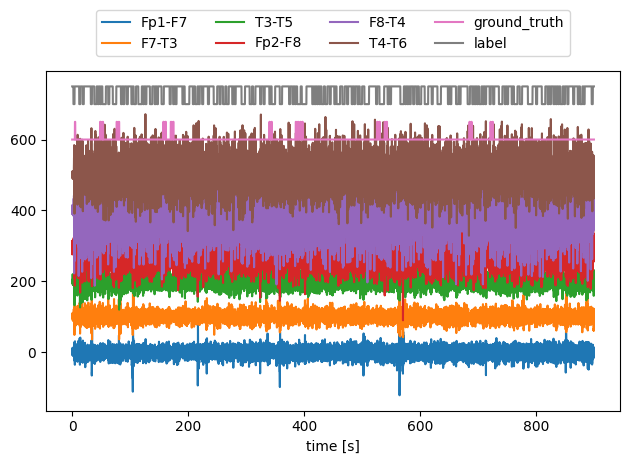

In [62]:
plot_eeg(data_learning_labeled08)

##### Plot LEARNED labels SE021_a1

In [56]:
data_learning_SE021_a1 = patient_data['SE021_a1']['training_data']
eeg_learning_SE021_a1 = detector.get_windows(patient_data['SE021_a1']['eeg_training'])
learned_labels21 = detector_results.iloc[1]['labels']

labels_frame = combine_windows_with_labels(eeg_learning_SE021_a1, learned_labels21)
data_learning_labeled21 = data_learning_SE021_a1.copy()
data_learning_labeled21['label'] = labels_frame['label']

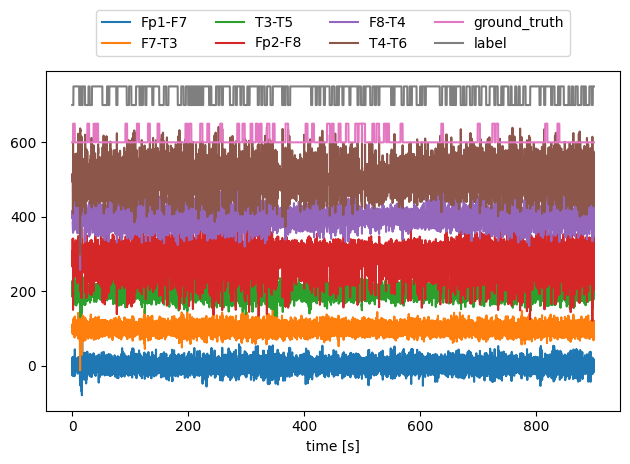

In [60]:
plot_eeg(data_learning_labeled21)

##### Plot LEARNED labels SE026_a1

In [74]:
patient_data[patient_id].keys()

dict_keys(['data', 'fs', 'training_data', 'testing_data', 'eeg_training', 'eeg_testing'])

In [70]:
data_learning_SE026_a1 = patient_data['SE026_a1']['training_data']
eeg_learning_SE026_a1 = detector.get_windows(patient_data['SE026_a1']['eeg_training'])
learned_labels26 = detector_results.iloc[2]['labels']

labels_frame = combine_windows_with_labels(eeg_learning_SE026_a1, learned_labels26)
data_learning_labeled26 = data_learning_SE026_a1.copy()
data_learning_labeled26['label'] = labels_frame['label']

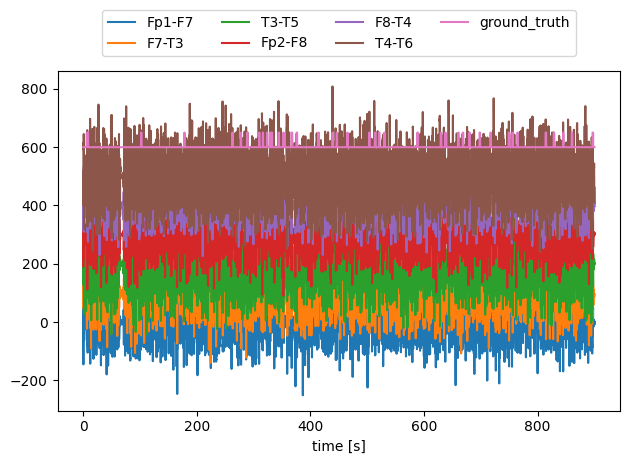

In [71]:
plot_eeg(data_learning_SE026_a1)

##### Plot LEARNED labels SE038_a1

In [97]:
data_learning_SE038_a1 = patient_data['SE038_a1']['training_data']
eeg_learning_SE038_a1 = detector.get_windows(patient_data['SE038_a1']['eeg_training'])
learned_labels38 = detector_results.iloc[3]['labels']

labels_frame = combine_windows_with_labels(eeg_learning_SE038_a1, learned_labels38)
data_learning_labeled38 = data_learning_SE038_a1.copy()
data_learning_labeled38['label'] = labels_frame['label']

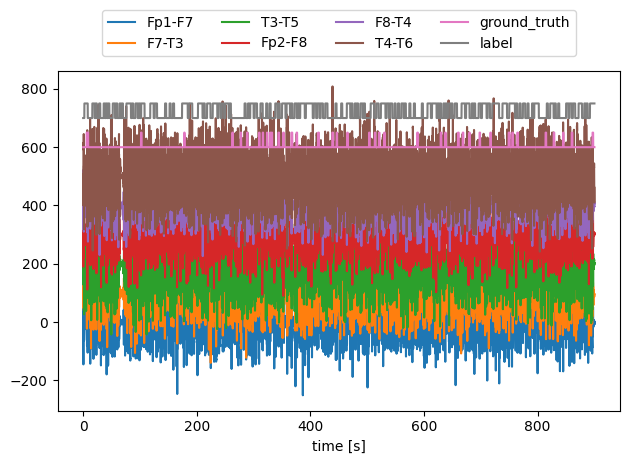

In [98]:
plot_eeg(data_learning_labeled38)

##### Plot PREDICTED Labels SE008_a1

In [99]:
data_testing_SE008_a1 = patient_data['SE008_a1']['testing_data']
eeg_testing_SE008_a1 = detector.get_windows(patient_data['SE008_a1']['eeg_testing'])
predicted_labels08 = detector_results.iloc[0]['predictions']

labels_frame = combine_windows_with_labels(eeg_testing_SE008_a1, predicted_labels08)
data_testing_labeled08 = data_testing_SE008_a1.copy()
data_testing_labeled08['label'] = labels_frame['label']

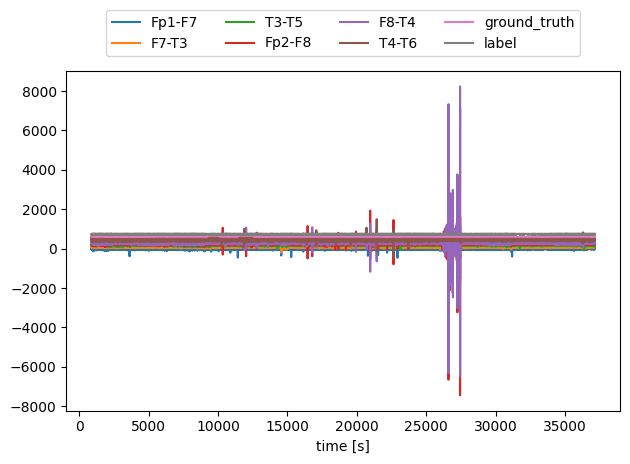

In [102]:
plot_eeg(data_testing_labeled08)

##### Plot PREDICTED Labels SE021_a1

In [88]:
data_testing_SE021_a1 = patient_data['SE021_a1']['testing_data']
eeg_testing_SE021_a1 = detector.get_windows(patient_data['SE021_a1']['eeg_testing'])
predicted_labels21 = detector_results.iloc[1]['predictions']

labels_frame = combine_windows_with_labels(eeg_testing_SE021_a1, predicted_labels21)
data_testing_labeled21 = data_testing_SE021_a1.copy()
data_testing_labeled21['label'] = labels_frame['label']

##### Plot PREDICTED Labels SE026_a1

In [104]:
data_testing_SE026_a1 = patient_data['SE026_a1']['testing_data']
eeg_testing_SE026_a1 = detector.get_windows(patient_data['SE026_a1']['eeg_testing'])
predicted_labels26 = detector_results.iloc[2]['predictions']

labels_frame = combine_windows_with_labels(eeg_testing_SE026_a1, predicted_labels26)
data_testing_labeled26 = data_testing_SE026_a1.copy()
data_testing_labeled26['label'] = labels_frame['label']

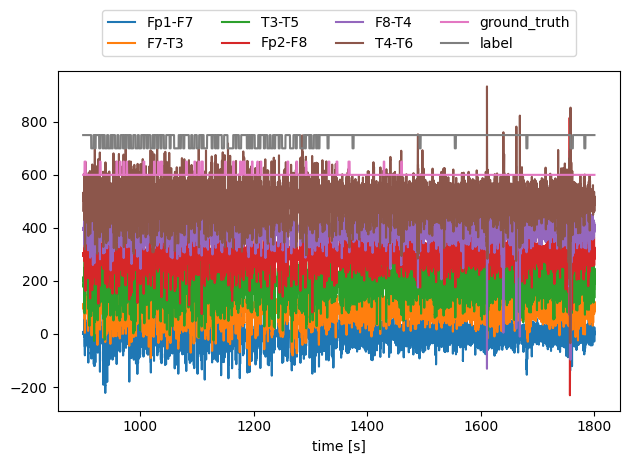

In [107]:
plot_eeg(data_testing_labeled26)

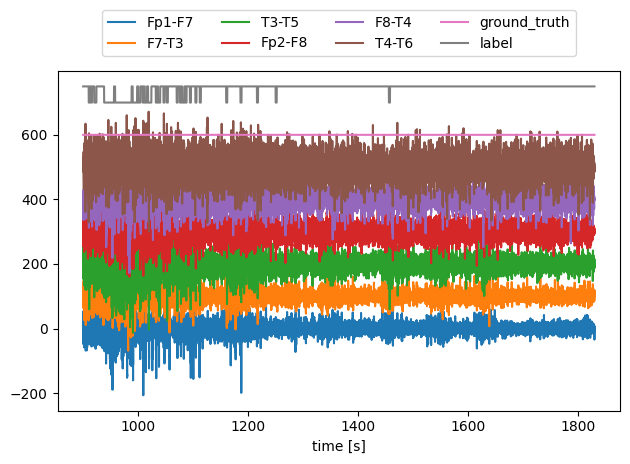

In [109]:
plot_eeg(data_testing_labeled38)

##### Plot PREDICTED Labels SE038_a1

In [108]:
data_testing_SE038_a1 = patient_data['SE038_a1']['testing_data']
eeg_testing_SE038_a1 = detector.get_windows(patient_data['SE038_a1']['eeg_testing'])
predicted_labels38 = detector_results.iloc[3]['predictions']

labels_frame = combine_windows_with_labels(eeg_testing_SE038_a1, predicted_labels38)
data_testing_labeled38 = data_testing_SE038_a1.copy()
data_testing_labeled38['label'] = labels_frame['label']

##### Plot t-SNE

In [122]:
detector_results['metric_d']

SE008_a1    [[1.884110950420531e-15, 6.553309928838275, 7....
SE021_a1    [[1.3322676295501877e-15, 7.030832040284373, 8...
SE026_a1    [[1.1801832636420706e-15, 10.869030132629273, ...
SE038_a1    [[5.0876810486276e-16, 11.88811310616606, 11.4...
Name: metric_d, dtype: object

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


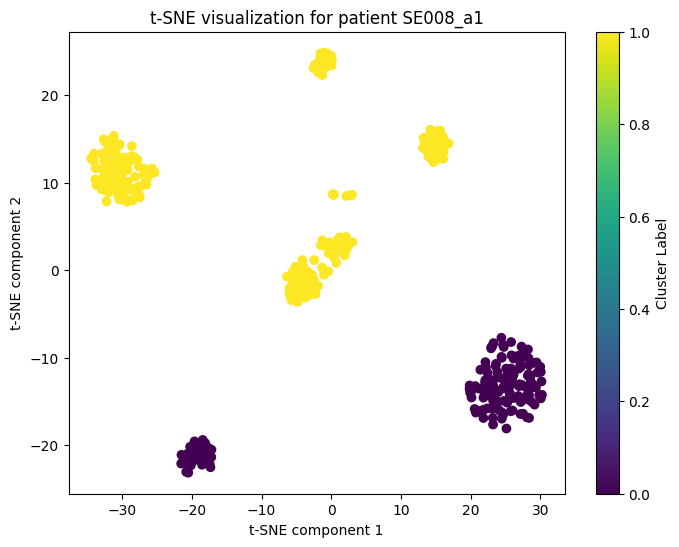

In [123]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


patient_id = 'SE008_a1'
metric_d = detector_results.loc[patient_id, 'metric_d']
labels = detector_results.loc[patient_id, 'labels']

# perform t-SNE on the distance matrix (metric_d)
tsne = TSNE(metric='precomputed', init='random', random_state=42)
tsne_results = tsne.fit_transform(metric_d)

# plot the t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='viridis', marker='o')
plt.colorbar(label='Cluster Label')
plt.title(f't-SNE visualization for patient {patient_id}')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.show()

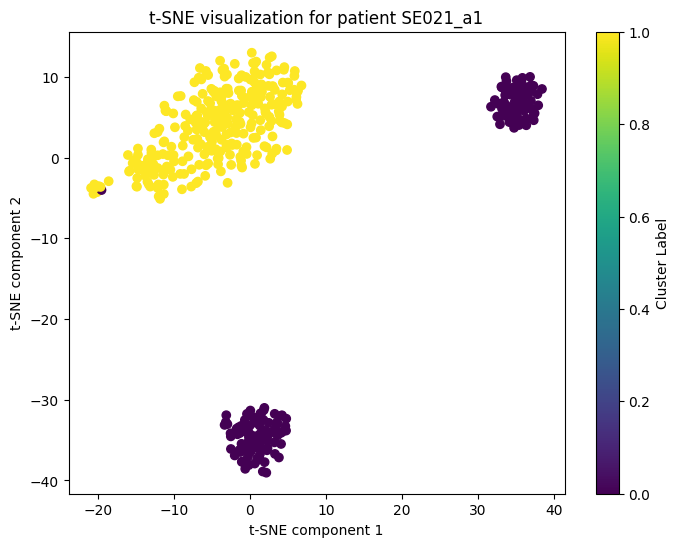

In [124]:
patient_id = 'SE021_a1'
metric_d = detector_results.loc[patient_id, 'metric_d']
labels = detector_results.loc[patient_id, 'labels']

# perform t-SNE on the distance matrix (metric_d)
tsne = TSNE(metric='precomputed', init='random', random_state=42)
tsne_results = tsne.fit_transform(metric_d)

# plot the t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='viridis', marker='o')
plt.colorbar(label='Cluster Label')
plt.title(f't-SNE visualization for patient {patient_id}')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.show()

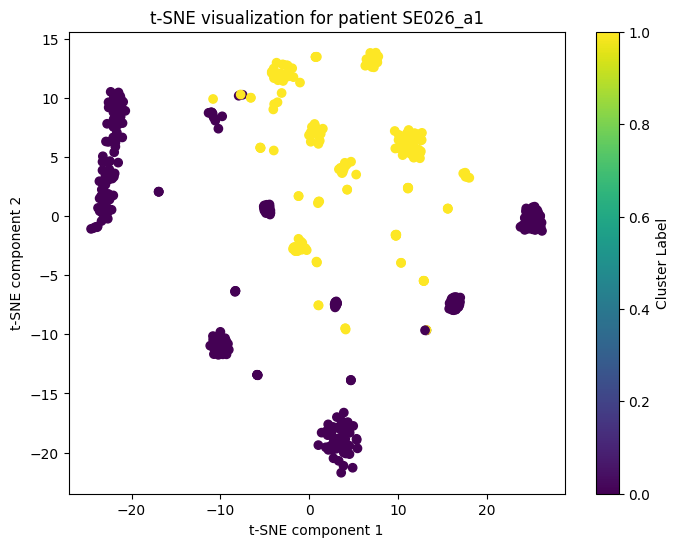

In [125]:
patient_id = 'SE026_a1'
metric_d = detector_results.loc[patient_id, 'metric_d']
labels = detector_results.loc[patient_id, 'labels']

# perform t-SNE on the distance matrix (metric_d)
tsne = TSNE(metric='precomputed', init='random', random_state=42)
tsne_results = tsne.fit_transform(metric_d)

# plot the t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='viridis', marker='o')
plt.colorbar(label='Cluster Label')
plt.title(f't-SNE visualization for patient {patient_id}')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.show()

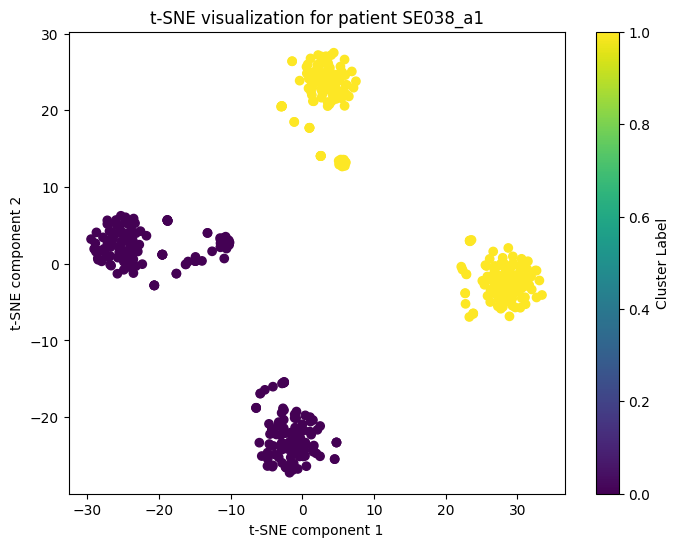

In [126]:
patient_id = 'SE038_a1'
metric_d = detector_results.loc[patient_id, 'metric_d']
labels = detector_results.loc[patient_id, 'labels']

# perform t-SNE on the distance matrix (metric_d)
tsne = TSNE(metric='precomputed', init='random', random_state=42)
tsne_results = tsne.fit_transform(metric_d)

# plot the t-SNE results
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='viridis', marker='o')
plt.colorbar(label='Cluster Label')
plt.title(f't-SNE visualization for patient {patient_id}')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')
plt.show()

## 3. Results

### Confusion matrix: 
Obtatining the confusion matrix to evaluate the performance of the detector.

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(predictions, labels, patient_id):
    cf = ConfusionMatrixDisplay.from_predictions(
        labels, predictions,  # Order is important: true labels first, then predicted
        values_format='d',
        cmap='viridis',
        display_labels=['No Burst', 'Burst']
    )

    # set the plot title
    cf.ax_.set_title(f'Confusion Matrix - {patient_id}')  

    # display the confusion matrix
    plt.show()  

    # save the plot
    cf.figure_.savefig(f"confusion_matrix_{patient_id}.png", dpi=300)

In [83]:
detector_results.head()

,predictions,labels,cov_matrices,metric_d
SE008_a1,"[1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, ...","[1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, ...","[[[23.909551782879888, 3.8603213245463768, 6.9...","[[1.884110950420531e-15, 6.553309928838275, 7...."
SE021_a1,"[1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, ...","[0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, ...","[[[129.1521418973401, 12.554749509751, -32.724...","[[1.3322676295501877e-15, 7.030832040284373, 8..."
SE026_a1,"[1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, ...","[0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, ...","[[[1.1200658842232343, -0.43501252623619957, 0...","[[1.1801832636420706e-15, 10.869030132629273, ..."
SE038_a1,"[1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, ...","[0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, ...","[[[0.931997246201145, 0.007485998913006375, 0....","[[5.0876810486276e-16, 11.88811310616606, 11.4..."


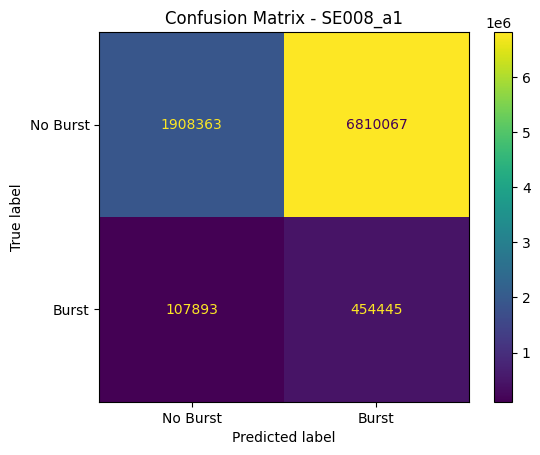

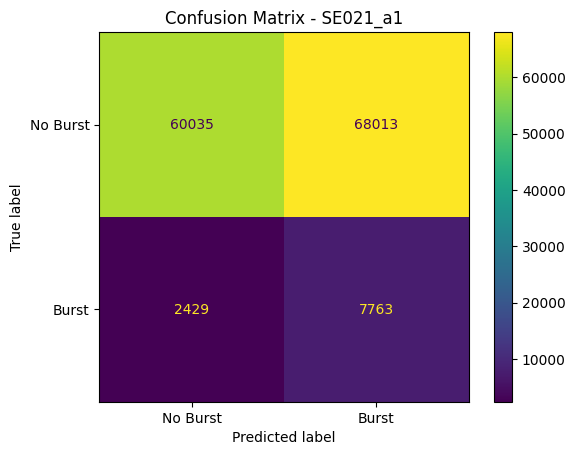

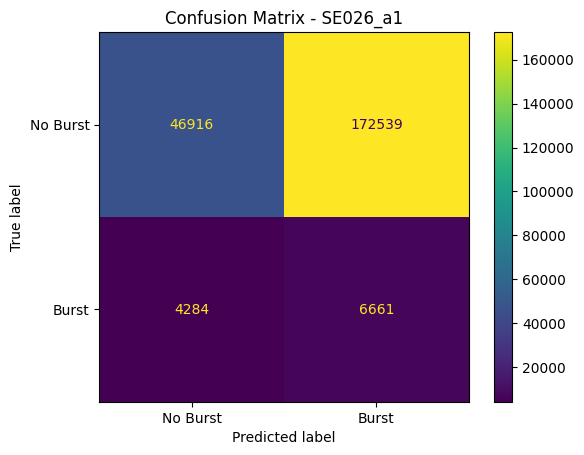

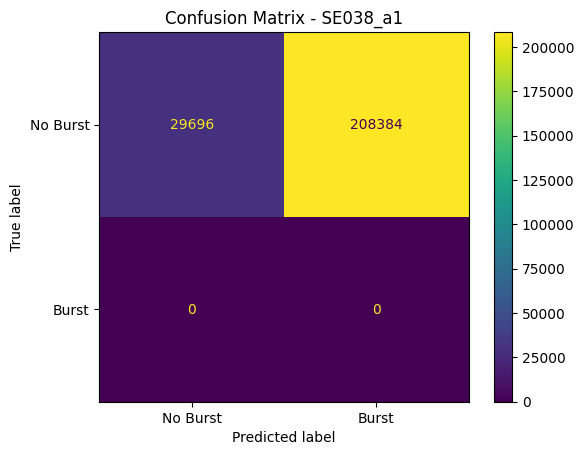

In [110]:
for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']
    plot_confusion_matrix(labels_predicted, labels_true, patient_id)

In [112]:
from sklearn.metrics import confusion_matrix

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    # Compute the confusion matrix
    cm = confusion_matrix(labels_true, labels_predicted)

    # Print the confusion matrix
    print(f"Confusion matrix for patient {patient_id}:")
    print(cm)

Confusion matrix for patient SE008_a1:
[[1908363 6810067]
 [ 107893  454445]]
Confusion matrix for patient SE021_a1:
[[60035 68013]
 [ 2429  7763]]
Confusion matrix for patient SE026_a1:
[[ 46916 172539]
 [  4284   6661]]
Confusion matrix for patient SE038_a1:
[[ 29696 208384]
 [     0      0]]


#### Save 'detector results' in data folder

In [113]:
results_for_analysis.keys()

dict_keys(['SE008_a1', 'SE021_a1', 'SE026_a1', 'SE038_a1'])

In [114]:
results_for_analysis

{'SE008_a1': {'predictions': array([1, 0, 0, ..., 1, 1, 1]),
  'labels': array([1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
         0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1,
         0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
         1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
         1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
         1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
         1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0,
         0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1,
         1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
         0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0,
         1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
         1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
         1, 0, 0, 0, 0, 1, 1,

In [115]:
def save_results_to_hdf5(results_dict, output_folder):
    """
    Saves EEG burst suppression detection results to individual HDF5 files for each patient,
    with a progress bar for visualization.

    Args:
        results_dict (dict): A dictionary where keys are patient IDs and values are 
                             dictionaries containing results (predictions, labels, etc.).
        output_folder (str): The path to the folder where HDF5 files will be saved.
    """

    os.makedirs(output_folder, exist_ok=True)

    for patient_id in tqdm.tqdm(results_dict, desc="Saving patient data"):
        results = results_dict[patient_id]
        filename = f"{patient_id}_results.hdf5"
        filepath = os.path.join(output_folder, filename)
        with h5py.File(filepath, 'w') as hf:
            for key, value in results.items():
                try:
                    hf.create_dataset(key, data=value)
                except TypeError as e:
                    print(f"Warning: Could not save '{key}' for {patient_id} due to TypeError: {e}")

In [116]:
OUTPUT_FOLDER = OUTPUT_FOLDER
save_results_to_hdf5(results_for_analysis, OUTPUT_FOLDER)

Saving patient data: 100%|██████████| 4/4 [00:03<00:00,  1.22it/s]


In [117]:
results_for_analysis_df = pd.DataFrame(results_for_analysis).T
results_for_analysis_df['patient_id'] = results_for_analysis_df.index
results_for_analysis_df.reset_index(drop=True, inplace=True)
results_for_analysis_df = results_for_analysis_df[['patient_id'] + [col for col in results_for_analysis_df.columns if col != 'patient_id']]
print(results_for_analysis_df)

  patient_id                                        predictions  \
0   SE008_a1  [1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, ...   
1   SE021_a1  [1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, ...   
2   SE026_a1  [1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, ...   
3   SE038_a1  [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, ...   

                                              labels  \
0  [1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, ...   
1  [0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, ...   
2  [0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, ...   
3  [0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, ...   

                                        cov_matrices  \
0  [[[23.909551782879888, 3.8603213245463768, 6.9...   
1  [[[129.1521418973401, 12.554749509751, -32.724...   
2  [[[1.1200658842232343, -0.43501252623619957, 0...   
3  [[[0.931997246201145, 0.007485998913006375, 0....   

                                            metric_d  \
0  [[1.884110950420531e-15, 6.553309928838275,

### Specificity and Sensitivity with Numpy

In [148]:
from sklearn.metrics import confusion_matrix

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    cm = confusion_matrix(labels_true, labels_predicted)

    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    recall = sensitivity
    precision = TP / (TP + FP)

    npv = TN / (TN + FN) if (TN + FN) > 0 else 0

    print(patient_id)
    print(cm)

    print(f"TP: Correctly predicted bursts ({TP})")
    print(f"FP: Incorrectly predicted bursts ({FP})")
    print(f"FN: Incorrectly predicted no-bursts ({FN})")
    print(f"TN: Correctly predicted no-bursts ({TN})")

    print(f"Sensitivity/Recall: {sensitivity:.2f}")
    print(f"Specificity: {specificity:.2f}")

    print(f"Precision: {precision:.2f}")
    
    print(f"NPV ({npv})")
    print('-'*20)

SE008_a1
[[1908363 6810067]
 [ 107893  454445]]
TP: Correctly predicted bursts (454445)
FP: Incorrectly predicted bursts (6810067)
FN: Incorrectly predicted no-bursts (107893)
TN: Correctly predicted no-bursts (1908363)
Sensitivity/Recall: 0.81
Specificity: 0.22
Precision: 0.06
NPV (0.9464884419438802)
--------------------
SE021_a1
[[60035 68013]
 [ 2429  7763]]
TP: Correctly predicted bursts (7763)
FP: Incorrectly predicted bursts (68013)
FN: Incorrectly predicted no-bursts (2429)
TN: Correctly predicted no-bursts (60035)
Sensitivity/Recall: 0.76
Specificity: 0.47
Precision: 0.10
NPV (0.9611136014344263)
--------------------
SE026_a1
[[ 46916 172539]
 [  4284   6661]]
TP: Correctly predicted bursts (6661)
FP: Incorrectly predicted bursts (172539)
FN: Incorrectly predicted no-bursts (4284)
TN: Correctly predicted no-bursts (46916)
Sensitivity/Recall: 0.61
Specificity: 0.21
Precision: 0.04
NPV (0.916328125)
--------------------
SE038_a1
[[ 29696 208384]
 [     0      0]]
TP: Correctly p

C:\Users\c_arz\AppData\Local\Temp\ipykernel_16008\1363273406.py:15: RuntimeWarning: invalid value encountered in scalar divide
  sensitivity = TP / (TP + FN)


### AUROC 

get the ground truth labels from `testing_data['ground_truth']`

In [ ]:
''''
from sklearn.metrics import auc, roc_curve

fpr, tpr, _ = roc_curve(true_labels, predicted_scores)
auroc = auc(fpr, tpr)
print(f"AUROC: {auroc:.2f}")
'''

In [131]:
from sklearn.metrics import roc_auc_score

auroc_scores = {}

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    try:
        auroc = roc_auc_score(labels_true, labels_predicted) 
    except ValueError as e:
        if "Only one class present in y_true" in str(e):
            print(f"Only one class present in y_true. ROC AUC score is not defined in that case.")
            print(f"Warning: Skipping ROC AUC calculation for Patient {patient_id}")
            continue
        else:
            raise  # Re-raise the exception if it's not the specific ValueError we're handling

    auroc_scores[patient_id] = round(auroc, 2) 

Only one class present in y_true. ROC AUC score is not defined in that case.


In [132]:
print(auroc_scores)

{'SE008_a1': 0.51, 'SE021_a1': 0.62, 'SE026_a1': 0.41}


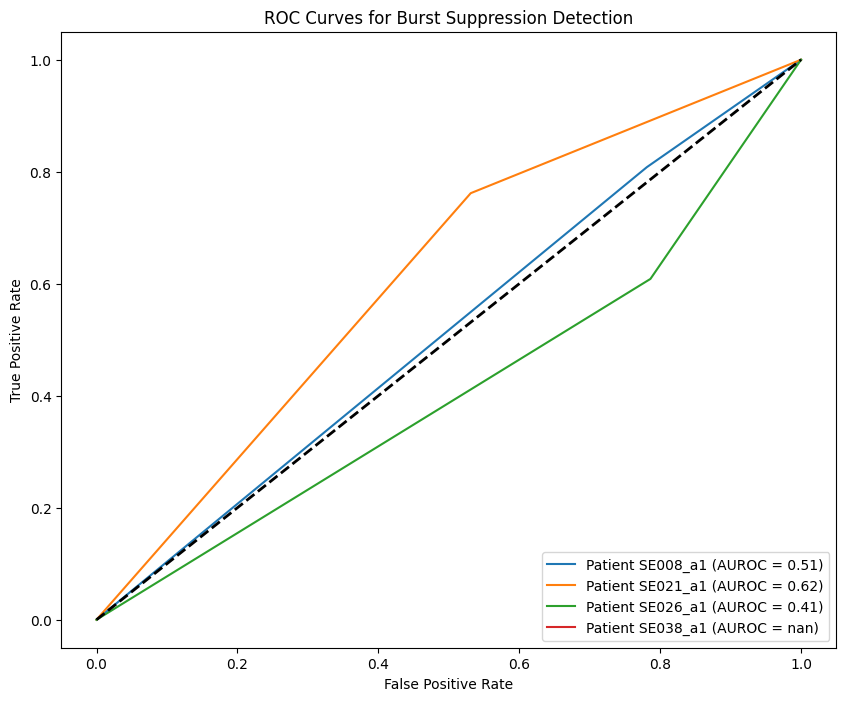

In [133]:
from sklearn.metrics import roc_curve, auc
from sklearn.exceptions import UndefinedMetricWarning
import warnings

plt.figure(figsize=(10, 8))

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=UndefinedMetricWarning)
            fpr, tpr, thresholds = roc_curve(labels_true, labels_predicted)
            auroc = auc(fpr, tpr) 
            
        plt.plot(fpr, tpr, label=f'Patient {patient_id} (AUROC = {auroc:.2f})')

    except ValueError as e:
        if "Only one class present in y_true" in str(e):
            print(f"Only one class present in y_true for Patient {patient_id}. ROC AUC score is not defined.")
            # You can choose to plot a default curve or skip plotting for this patient
            # plt.plot([0, 1], [0, 1], 'k--', label=f'Patient {patient_id} (AUROC = N/A)') 
            continue
        else:
            raise  

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal dashed line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Burst Suppression Detection')
plt.legend(loc="lower right")
plt.show()

### Mean Absolute Error (MAE) of BPM

$MAE_{BPM} = \text{mean}(|BPM_{groundtruth} - BPM_{predicted}|)$

In [ ]:
# Calculate Bursts Per Minute (BPM)
def calculate_bpm(data, bursts_column, window_size_seconds=2, sample_rate=256):
    total_eeg_duration = (len(data) / sample_rate / 60)
    bursts = []
    in_burst = False
    window_start_time = None

    for i, row in data.iterrows():
        if row[bursts_column] == 1 and not in_burst:
            # Start of a new burst
            in_burst = True
            window_start_time = i 
            bursts.append(i)
        elif row[bursts_column] == 0 and in_burst:
            # End of a burst
            in_burst = False
        elif in_burst and (i - window_start_time).total_seconds() >= window_size_seconds:
            # Still in a burst, but outside the current window
            in_burst = False

    total_bursts = len(bursts)

    bpm = total_bursts / total_eeg_duration
    return bpm

In [134]:
from joblib import Parallel, delayed
import pandas as pd

def calculate_bpm(data, bursts_column, window_size_seconds=2, sample_rate=256, n_jobs=-1):
    total_eeg_duration = (len(data) / sample_rate / 60)
    
    # Define a helper function to calculate bursts in a chunk of data
    def process_chunk(chunk_start, chunk_end):
        bursts = []
        in_burst = False
        window_start_time = None

        for i in range(chunk_start, chunk_end):
            row = data.iloc[i]
            if row[bursts_column] == 1 and not in_burst:
                # Start of a new burst
                in_burst = True
                window_start_time = i
                bursts.append(i)
            elif row[bursts_column] == 0 and in_burst:
                # End of a burst
                in_burst = False
            elif in_burst and (i - window_start_time) >= window_size_seconds * sample_rate:
                # Still in a burst, but outside the current window
                in_burst = False
        return bursts
    
    # Split data into chunks for parallel processing
    n_rows = len(data)
    chunk_size = n_rows // 10  # Divide into 10 chunks or adjust based on the data size
    chunks = [(i, min(i + chunk_size, n_rows)) for i in range(0, n_rows, chunk_size)]
    
    # Parallel processing of chunks
    results = Parallel(n_jobs=n_jobs)(delayed(process_chunk)(start, end) for start, end in chunks)

    # Flatten the list of bursts and calculate bpm
    all_bursts = [burst for chunk_bursts in results for burst in chunk_bursts]
    total_bursts = len(all_bursts)
    bpm = total_bursts / total_eeg_duration
    
    return bpm

Calculate the true rate of BPM using the ground truth. 

Calculate the predicted BPM rate based on the predicted labels.

Calculate the MAE and append to `mae_scores` dictionary.

In [135]:
import numpy as np

mae_scores = {}

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    # Calculate the ground truth and predicted BPM
    ground_truth_bpm = calculate_bpm(data_testing_cropped_labeled, 'ground_truth')
    predicted_bpm = calculate_bpm(data_testing_cropped_labeled, 'label')

    # Initialize mae_scores[patient_id] if it doesn't exist
    if patient_id not in mae_scores:
        mae_scores[patient_id] = {}

    # Store the calculated BPM values
    mae_scores[patient_id]['ground_truth_bpm'] = ground_truth_bpm
    mae_scores[patient_id]['predicted_bpm'] = predicted_bpm

    # Calculate the mean absolute error for BPM
    mae_bpm = np.mean(np.abs(ground_truth_bpm - predicted_bpm))

    # Store the MAE value for each patient
    mae_scores[patient_id]['mae_bpm'] = mae_bpm

    # Print the result for each patient
    print(f"Patient {patient_id} - Mean Absolute Error (BPM): {mae_bpm:.2f}")



Patient SE008_a1 - Mean Absolute Error (BPM): 21.57
Patient SE021_a1 - Mean Absolute Error (BPM): 13.67
Patient SE026_a1 - Mean Absolute Error (BPM): 21.00
Patient SE038_a1 - Mean Absolute Error (BPM): 26.52


### F1-Scores

In [146]:
from sklearn.metrics import f1_score

f1_scores = {}

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    f1_scores[patient_id] = {}

    f1 = f1_score(labels_true, labels_predicted)

    print(f"Patient {patient_id} - F1 Score: {f1:.2f}")
    print('-'*35)

Patient SE008_a1 - F1 Score: 0.12
-----------------------------------
Patient SE021_a1 - F1 Score: 0.18
-----------------------------------
Patient SE026_a1 - F1 Score: 0.07
-----------------------------------
Patient SE038_a1 - F1 Score: 0.00
-----------------------------------


### Classification Report

Very Low Precision for Bursts: The precision for the "burst" class (1.0) is extremely low (0.06). This suggests that when the algorithm predicts a burst, it's very often incorrect. This aligns with the high number of false positives (115,517) compared to true positives (83).


In [141]:
from sklearn.metrics import classification_report

classification_reports = {}

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    cr = classification_report(labels_true, labels_predicted)
    classification_reports[patient_id] = cr

    print(f"Classification Report {patient_id}:")
    print(cr)
    print('-'*60)

Classification Report SE008_a1:
              precision    recall  f1-score   support

           0       0.95      0.22      0.36   8718430
           1       0.06      0.81      0.12    562338

    accuracy                           0.25   9280768
   macro avg       0.50      0.51      0.24   9280768
weighted avg       0.89      0.25      0.34   9280768

------------------------------------------------------------
Classification Report SE021_a1:
              precision    recall  f1-score   support

           0       0.96      0.47      0.63    128048
           1       0.10      0.76      0.18     10192

    accuracy                           0.49    138240
   macro avg       0.53      0.62      0.41    138240
weighted avg       0.90      0.49      0.60    138240

------------------------------------------------------------
Classification Report SE026_a1:
              precision    recall  f1-score   support

           0       0.92      0.21      0.35    219455
           1       

c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\c_arz\Documents\KISPI\Burst_Suppression_Project\Thesis\UnsuperDL-EEG-BSUPP\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples

##### Cohen's Kappa

In [150]:
from sklearn.metrics import cohen_kappa_score

for patient_id, patient_info in results_for_analysis.items():
    data_testing_cropped_labeled = patient_info['data_testing_cropped_labeled']
    labels_true = data_testing_cropped_labeled['ground_truth']
    labels_predicted = data_testing_cropped_labeled['label']

    # Calculate Cohen's Kappa
    kappa = cohen_kappa_score(labels_true, labels_predicted)

    print(f"{patient_id} Cohen's Kappa: {kappa:.2f}")
    print('-'*30)

SE008_a1 Cohen's Kappa: 0.00
------------------------------
SE021_a1 Cohen's Kappa: 0.06
------------------------------
SE026_a1 Cohen's Kappa: -0.02
------------------------------
SE038_a1 Cohen's Kappa: 0.00
------------------------------
